In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cleaned_retail_data.csv")

In [3]:
df

,order_id,order_date,product_id,product_name,category,price,quantity,channel,city,customer_id,stock_available,sales,stock_status,total_sales
0,1,10/5/2024,1077,Shoes,Electronics,3610.49,2,Online,Delhi,6959,422,7220.98,Overstock,7220.98
1,2,31/12/2024,1035,Shoes,Electronics,2164.15,2,Store,Delhi,5426,65,4328.30,Optimal,4328.30
2,3,10/11/2024,1094,Sofa,Electronics,107.99,1,Store,Bangalore,5728,268,107.99,Optimal,107.99
3,4,2/5/2022,1027,Headphones,Electronics,1909.50,3,Store,Delhi,5880,178,5728.50,Optimal,5728.50
4,5,12/4/2023,1097,Watch,Sports,432.02,4,Store,Bangalore,5561,212,1728.08,Optimal,1728.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,11/8/2024,1005,Shoes,Sports,1607.60,3,Online,Mumbai,6806,466,4822.80,Overstock,4822.80
19996,19997,22/01/2022,1090,Shirt,Clothing,3636.80,1,App,Hyderabad,6802,68,3636.80,Optimal,3636.80
19997,19998,15/06/2022,1091,Sofa,Electronics,2229.07,3,Store,Bangalore,6626,269,6687.21,Optimal,6687.21
19998,19999,22/08/2022,1074,Shirt,Sports,3940.49,2,Online,Hyderabad,5312,397,7880.98,Overstock,7880.98


In [4]:
sns.set_theme(style="whitegrid", palette="Set2")

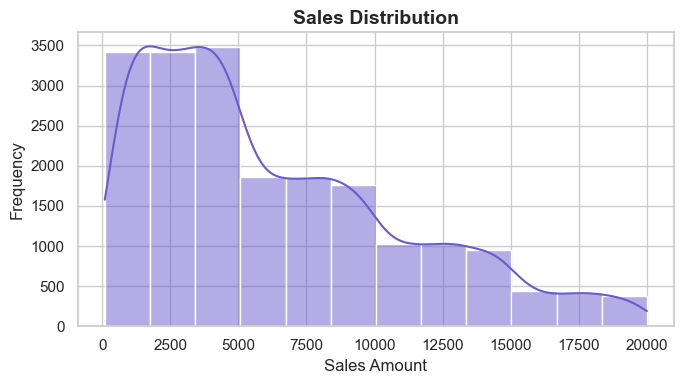

In [5]:
# Sales distribution analysis
plt.figure(figsize=(7,4))
sns.histplot(df['sales'], bins=12, kde=True, color="#6A5ACD")
plt.title("Sales Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

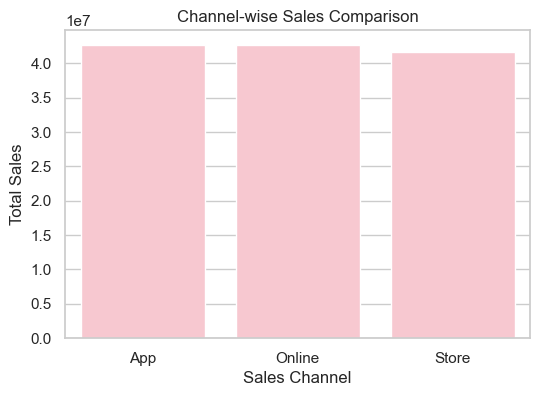

In [6]:
# Channel wise sales comparison 
channel_sales = df.groupby('channel')['sales'].sum().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(x='channel', y='sales', data=channel_sales, color="pink")
plt.title("Channel-wise Sales Comparison")
plt.xlabel("Sales Channel")
plt.ylabel("Total Sales")
plt.show()

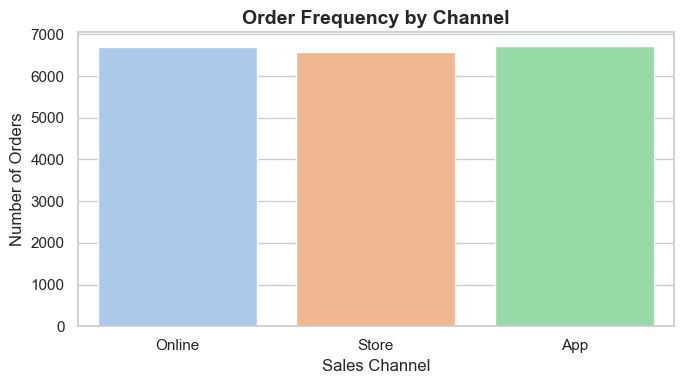

In [7]:
# Order by frequency channel 
plt.figure(figsize=(7,4))

sns.countplot(
    x='channel',
    hue='channel',     
    data=df,
    palette="pastel",
    legend=False        
)


plt.title("Order Frequency by Channel", fontsize=14, fontweight="bold")
plt.xlabel("Sales Channel")
plt.ylabel("Number of Orders")
plt.tight_layout()

plt.show()

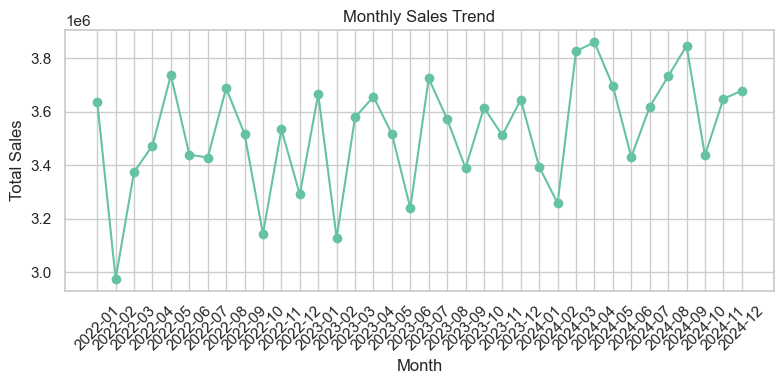

In [8]:
# Monthly sales trend
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['year_month'] = df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('year_month')['sales'].sum()
plt.figure(figsize=(8,4))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

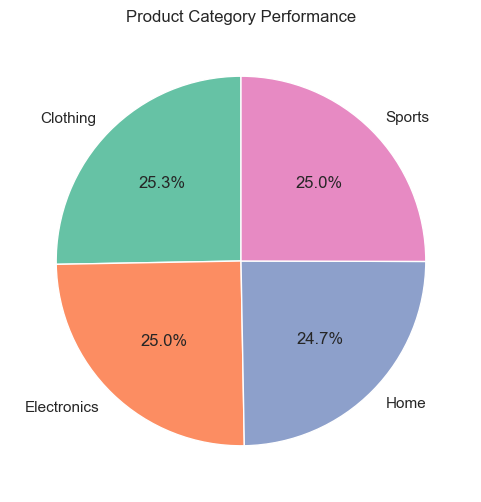

In [9]:
# Product category performance 
category_sales = df.groupby('category')['sales'].sum()
plt.figure(figsize=(6,6))
plt.pie(
    category_sales.values,
    labels=category_sales.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Product Category Performance")
plt.show()

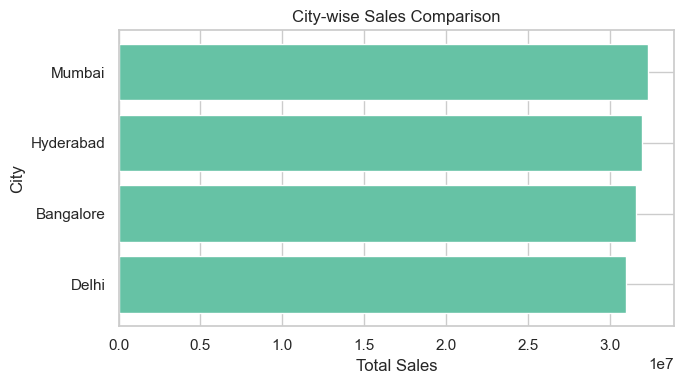

In [10]:
# City wise sales comparison
city_sales = df.groupby('city')['sales'].sum().sort_values()
plt.figure(figsize=(7,4))
plt.barh(city_sales.index, city_sales.values)
plt.title("City-wise Sales Comparison")
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.tight_layout()
plt.show()

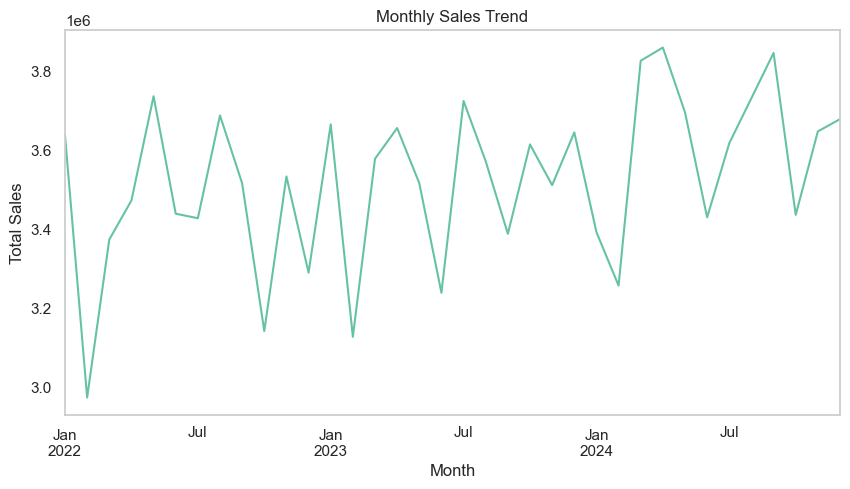

In [11]:
#1️ Monthly Sales Trend (Using `order_date` & `total_sales`)

df['order_date'] = pd.to_datetime(df['order_date'])
df['year_month'] = df['order_date'].dt.to_period('M')

monthly_sales = df.groupby('year_month')['total_sales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid()
plt.show()